In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#000000'

In [7]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [40]:
fig = px.histogram(
    medical_df,
    x='age',
    nbins=47,
    title='Distribution of Age',
    marginal='box'
)
fig.update_layout(bargap=0.1)

In [41]:
fig_2 = px.histogram(
    medical_df,
    x='bmi',
    marginal='box',
    title='Distribution of BMI'
)
fig_2.update_layout(bargap=0.1)

In [42]:
fig_3 = px.histogram(
    medical_df,
    x='charges',
    color='smoker',
    title='Annual Charges',
    marginal='box'
)
fig_3.update_layout(bargap=0.1)

In [43]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [44]:
px.histogram(medical_df, x='smoker', color='sex', title='Smokers')

In [45]:
fig_4 = px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    title='Age vs. Smoker',
    hover_data=['sex'],
    opacity=0.8,
)
fig_4.update_layout(bargap=0.1)
fig_4.update_traces(marker_size=5)

In [46]:
fig_5 = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title='BMI vs Charges'
)
fig_5.update_traces(marker_size=5)

In [47]:
# scatter vs violin
px.scatter(medical_df, x='children', y='charges')

In [48]:
px.violin(medical_df, x='children',y='charges')

In [49]:
# correlation between charges and age
medical_df.charges.corr(medical_df.age)

np.float64(0.29900819333064754)

In [50]:
# correlation between charges and bmi
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

In [51]:
# correlation between charges and children
medical_df.charges.corr(medical_df.children)

np.float64(0.0679982268479048)

In [52]:
# trying to correlate charges and smoker
medical_df.charges.corr(medical_df.smoker)

ValueError: could not convert string to float: 'yes'

In [53]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [54]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

Text(0.5, 1.0, 'Correlation Matrix')

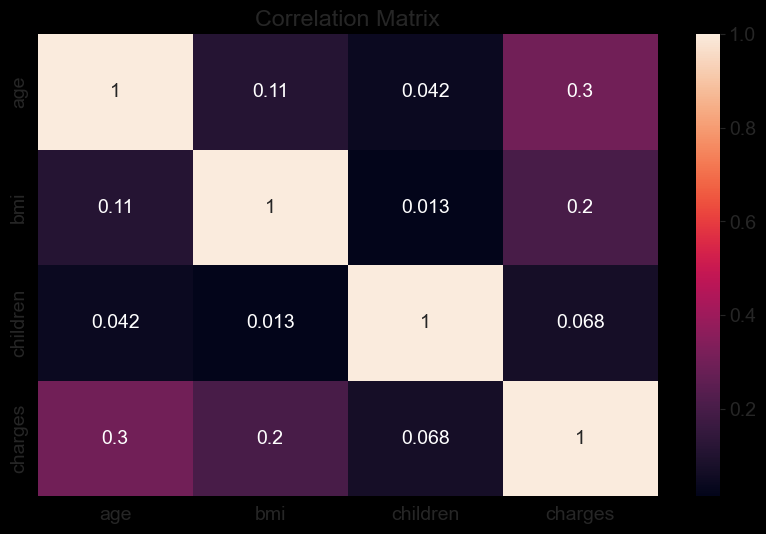

In [55]:
sns.heatmap(medical_df.drop(columns=['sex', 'smoker', 'region']).corr(), annot=True)
plt.title('Correlation Matrix')

<Axes: xlabel='age', ylabel='charges'>

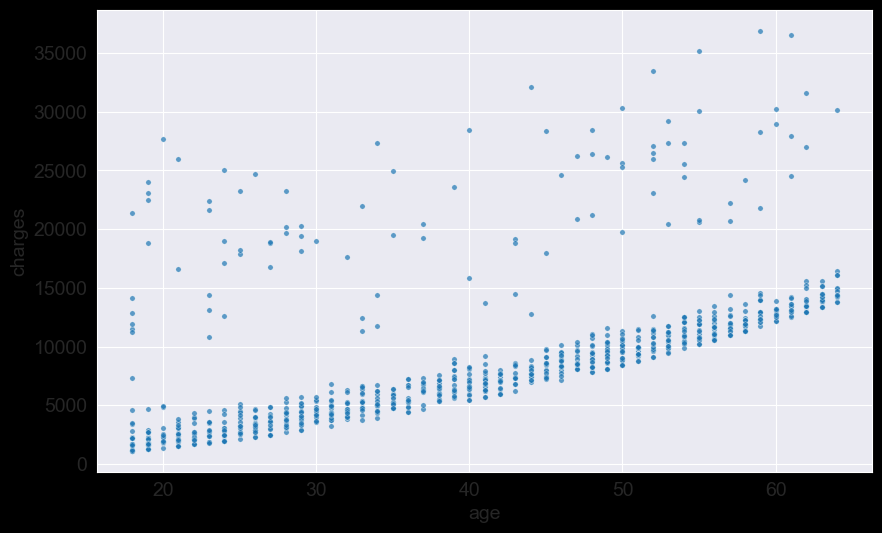

In [56]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
sns.scatterplot(data=non_smoker_df, x='age', y='charges', s=15, alpha=0.7)

In [57]:
def estimate_charges(a, w, b):
    return w*a+b

In [58]:
w=50
b=100

In [59]:
estimate_charges(30, w, b)

1600

In [60]:
ages=non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [61]:
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [62]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

Text(0, 0.5, 'Estimated Charges:')

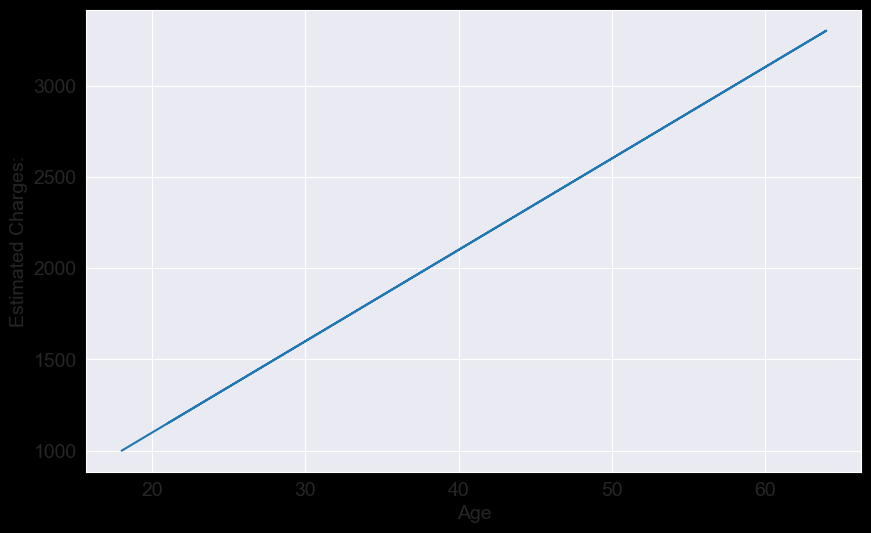

In [63]:
plt.plot(ages, estimated_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charges:')

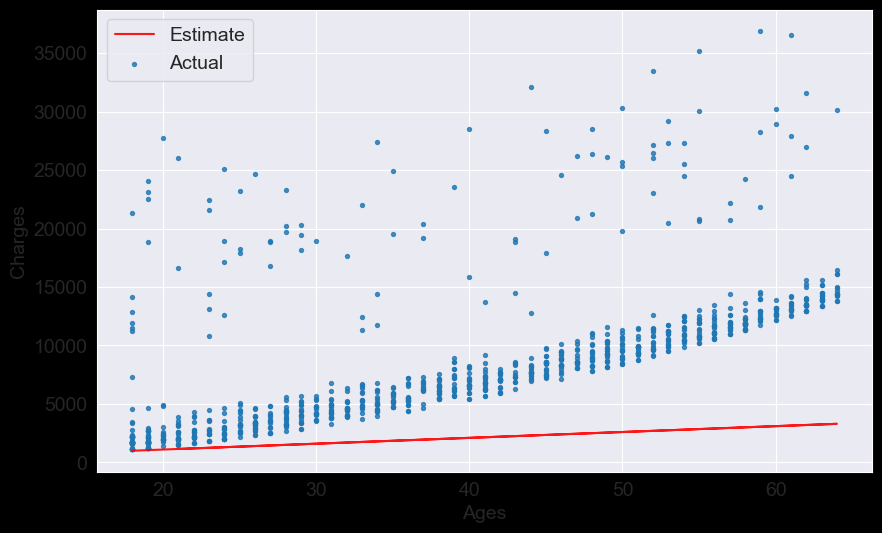

In [64]:
target = non_smoker_df.charges
plt.plot(ages, estimated_charges, alpha=0.9, c='r')
plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [65]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, alpha=0.9, c='r')
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

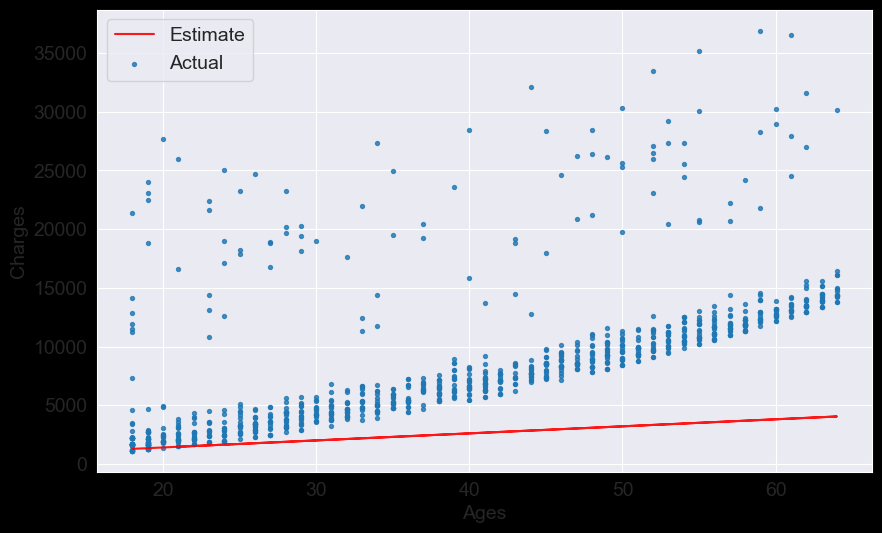

In [66]:
try_parameters(60, 200)

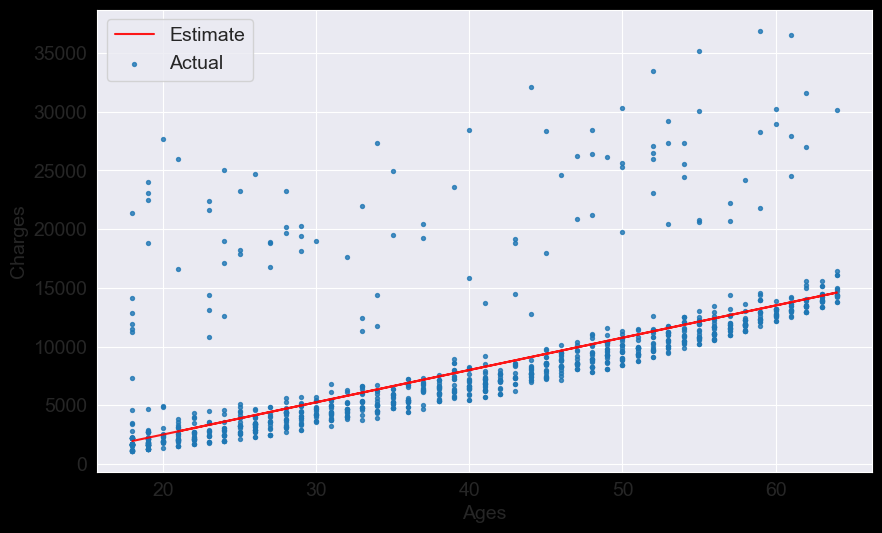

In [67]:
try_parameters(275, -3000)

In [68]:
targets = non_smoker_df.charges
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [69]:
predictions = estimated_charges
predictions

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [70]:
import numpy as np

In [71]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [72]:
w = 50
b = 100

In [73]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [74]:
rmse(targets, predicted)

np.float64(8461.949562575493)

In [75]:
def try_parameters(w,b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predcitions = estimate_charges(ages, w, b)

    plt.plot(ages, predcitions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])

    loss = rmse(target, predcitions)
    print(f'mse={loss}')

mse=4670.521202520753


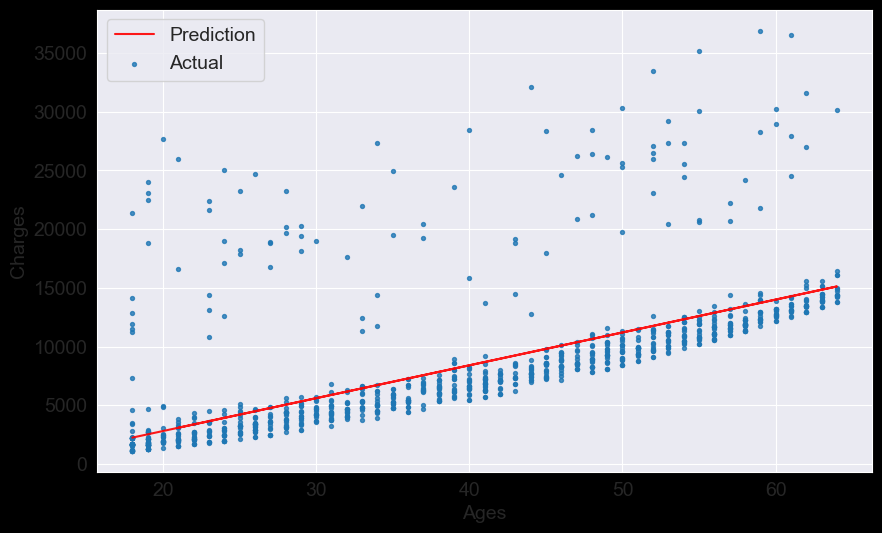

In [76]:
try_parameters(280, -2800)

In [77]:
from sklearn.linear_model import LinearRegression

In [78]:
model = LinearRegression()

In [79]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



In [80]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges

print(f'inputs.shape: {inputs.shape}')
print(f'targets.shape: {targets.shape}')

inputs.shape: (1064, 1)
targets.shape: (1064,)


In [81]:
model.fit(inputs,targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
model.predict(np.array([[23],[37],[61]]))

/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [83]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [84]:
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [85]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [86]:
# w
model.coef_

array([267.24891283])

In [87]:
# b
model.intercept_

np.float64(-2091.4205565650773)

mse=4662.505766636395


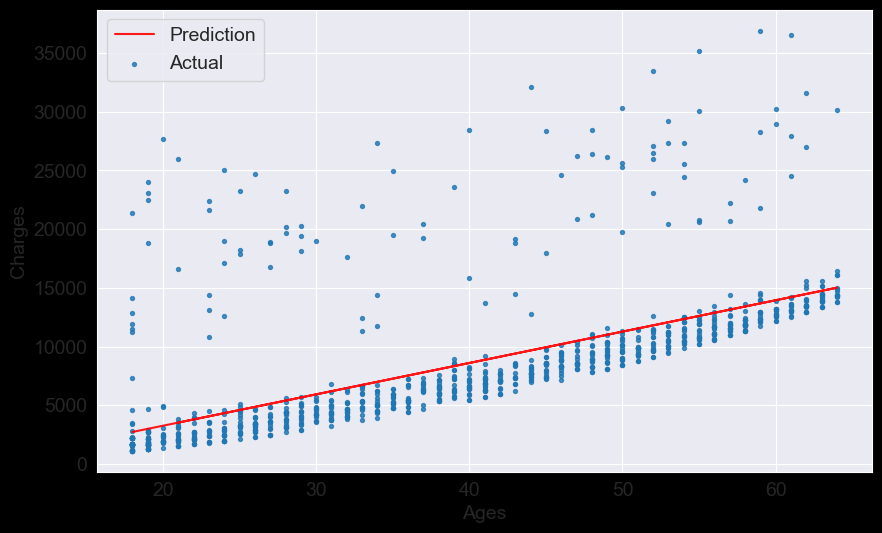

In [88]:
try_parameters(model.coef_, model.intercept_)

In [89]:
from sklearn.linear_model import SGDRegressor
model2 = SGDRegressor()
model2.fit(inputs, targets)
model2.predict(inputs)

array([ 8168.67779806, 13179.07808562, 15684.2782294 , ...,
        8168.67779806,  8168.67779806,  9671.79788433], shape=(1064,))

In [90]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [91]:
# w
print(model.coef_, model2.coef_)

[267.24891283] [501.04002876]


In [92]:
# b
print(model.intercept_, model2.intercept_)

-2091.4205565650773 [-850.04271954]


mse=11906.221819734561


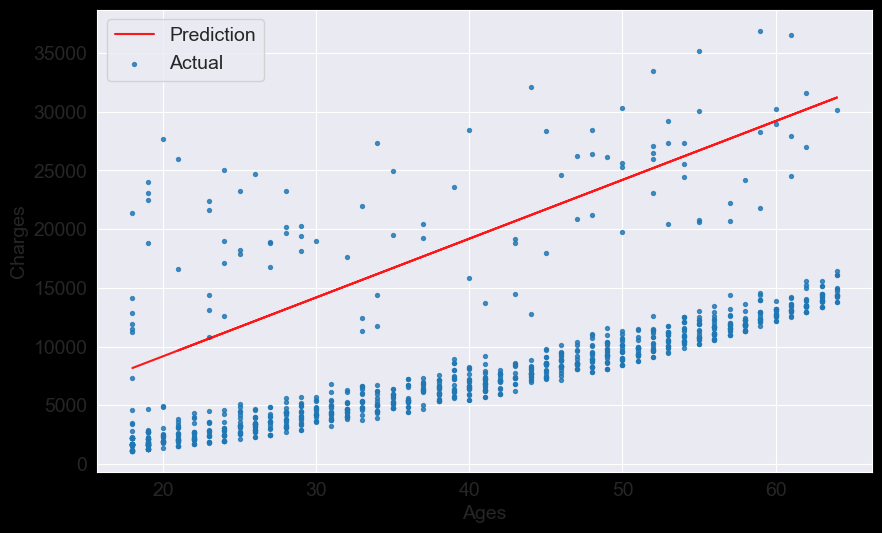

In [93]:
try_parameters(model2.coef_,model2.intercept_)

In [94]:
inputs, targets = non_smoker_df[['age']], non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

loss: 4662.505766636395


In [95]:
# adding BMI to the formula, liek adding age + model


In [96]:
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

loss: 4662.3128354612945


In [97]:
# why bmi didnt effect that much? lets see the correlation
non_smoker_df.charges.corr(non_smoker_df.bmi)
# weak correalation

np.float64(0.08403654312833268)

In [98]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)

In [99]:
inputs, targets = non_smoker_df[['bmi']], non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

loss: 5969.772531913293


In [ ]:
inputs, targets = non_smoker_df[['bmi']], non_smoker_df['charges']
model2 = SGDRegressor().fit(inputs, targets)
predictions = model2.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

'''
When we used only BMI it was much worse
'''

loss: 7028.754487039463


In [101]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542205)

In [102]:
fig = px.strip(non_smoker_df, x='children', y='charges', title='Children vs. Charges')
fig.update_traces(marker_size=4)

In [ ]:
inputs, targets = non_smoker_df[['age', 'bmi','children']], non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

'''
we added children to the prediction and got a bit more less loss
'''

loss: 4608.470405038247


In [ ]:
inputs, targets = medical_df[['age', 'bmi','children']], medical_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print(f'loss: {loss}')

'''
when we used the whole medical DataFrame we saw that the loss is much worse than the specific non_smoker_df
'''

loss: 11355.317901125973


In [ ]:
px.scatter(medical_df, x='age', y='charges', color='smoker')

'''
using this scatter plot we can see that line is going to be in the middle, that's why loss is that much higher
'''

In [ ]:
'''
Using categorical feratures for ML

when we have anly 2 values like yes/no or 1/0  ------ it is Binary category
    So we can use One Hot Encoding (1,0)


    And we have natural order (cold, neutral, wamt, hot) then they can be converted to 1,2,3,4 preserving the order. These are called ordianls.
    
'''

<Axes: xlabel='smoker', ylabel='charges'>

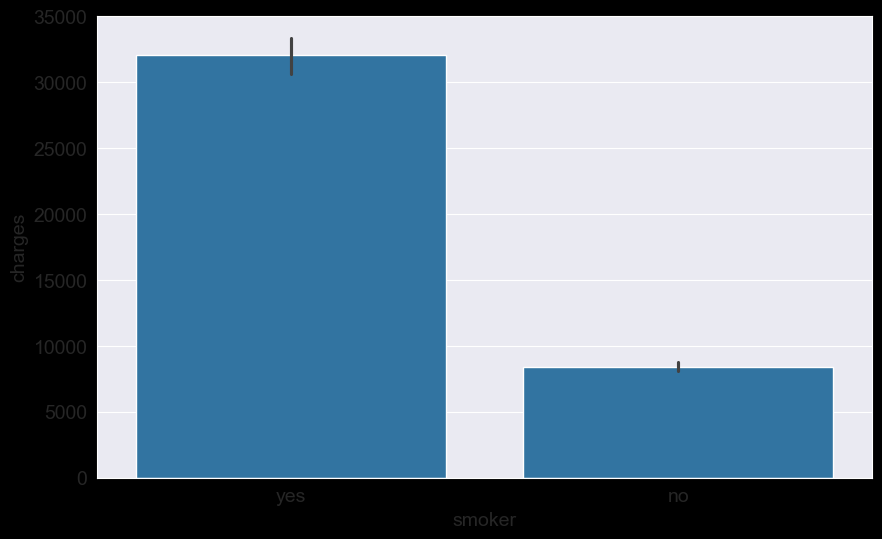

In [107]:
sns.barplot(data=medical_df, x='smoker', y='charges')

In [108]:
smoker_codes = {'no':0, 'yes':1}
medical_df['smoker_codes'] = medical_df.smoker.map(smoker_codes)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [109]:
medical_df.charges.corr(medical_df.smoker_codes)

np.float64(0.7872514304984772)

In [ ]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_codes']], medical_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss=rmse(targets, predictions)
print('loss=', loss)

'''
So loss is now 50% lower for the whole DF that's why we never ignore the categorical data
'''

loss= 6056.439217188081


<Axes: xlabel='sex', ylabel='charges'>

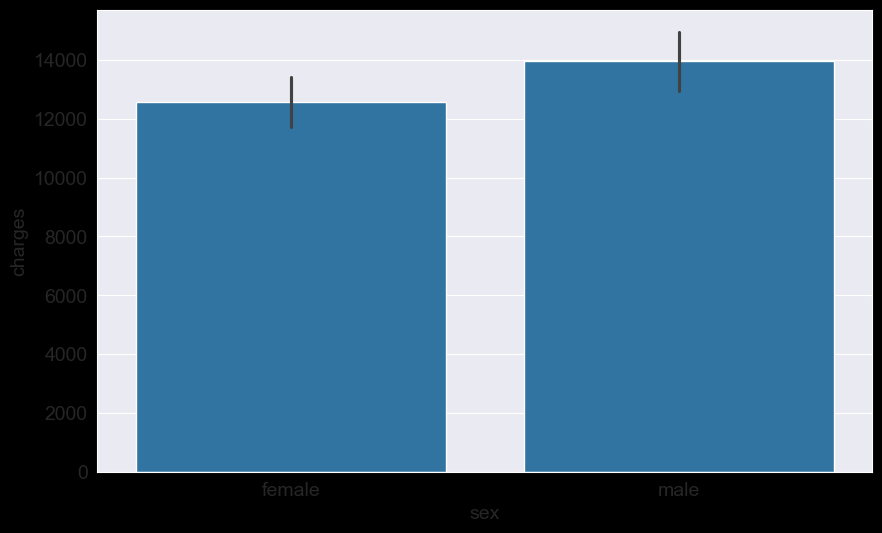

In [111]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [116]:
sex_codes = {'female':0,'male':1}
medical_df['sex_codes'] = medical_df.sex.map(sex_codes)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [117]:
medical_df.charges.corr(medical_df.sex_codes)

np.float64(0.057292062202025366)

In [118]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_codes', 'sex_codes']], medical_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss=rmse(targets, predictions)
print('loss=', loss)

loss= 6056.100708754546


<Axes: xlabel='region', ylabel='charges'>

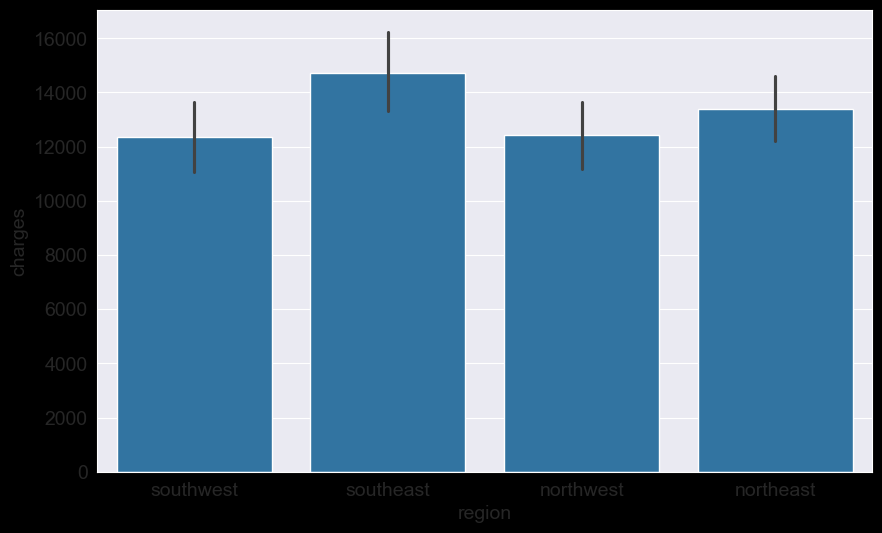

In [ ]:
sns.barplot(data=medical_df, x='region', y='charges')

'''
with the barplot below we can see that maybe region is also the factor to predictions. So we use one hot encoding to differenciate the regions into numbers
'''

In [120]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [122]:
enc.transform([['northeast'],
               ['northwest']]).toarray()

/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but OneHotEncoder was fitted with feature names



array([[1., 0., 0., 0.],
       [0., 1., 0., 0.]])

In [ ]:
# here we can see what numbers did the column tranformed into

one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [126]:
# now we need to insert into whole dataframe (medical_df)
medical_df[['northeast','northwest','southeast','southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0
